<a href="https://colab.research.google.com/github/SauravSG/Deep-Learning/blob/main/CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CIFAR-10**

**CIFAR-10** dataset consist of 60,000, 32x32 images comprises of 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck)

Out of 60,000:

50,000 is Training data.

10,000 is Testing data.

Since CIFAR-10 is a built-in torchvision dataset stored as binary files
(not as folders organized by class), we use the CIFAR10() class directly
instead of ImageFolder. ImageFolder is only needed when you have your own
images organized in class-named folders.

In [1]:
# Let's first import neccessary libraries

import torch
from torch import nn
from torchvision.datasets import CIFAR10

In [2]:
# let's transform the incoming images
'''
Note: We don't need to resize the images to 64x64 as the images in the dataset are already in 32x32. We can skip the transforms.Resize(size=(64x64)) part
'''

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

In [3]:
# we'll need to get the dataset somewhere

train_data = CIFAR10(root = './data',
                     train = True,
                     transform = train_transform,
                     target_transform = None,
                     download = True)

test_data = CIFAR10(root = './data',
                    train = False,
                    transform = test_transform,
                    target_transform = None,
                    download = True)

train_data, test_data

'''
Almost — but it's slightly broader than just loss functions. The fuller version:
target_transform is needed when anything downstream expects targets in a different format than plain integers — that could be:

the loss function (e.g. BCELoss needs one-hot)
the model output format (e.g. multi-label)
'''

"\nAlmost — but it's slightly broader than just loss functions. The fuller version:\ntarget_transform is needed when anything downstream expects targets in a different format than plain integers — that could be:\n\nthe loss function (e.g. BCELoss needs one-hot)\nthe model output format (e.g. multi-label)\n"

In [4]:
train_data.classes # gives the all classes names in the dataset

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [5]:
train_data.class_to_idx # the index value of each class

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [6]:
train_data.targets[:10] # printing the first 10 targets

[6, 9, 9, 4, 1, 1, 2, 7, 8, 3]

In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img, label = train_data[0]


In [8]:
img.shape, label

(torch.Size([3, 32, 32]), 6)

In [9]:
newimg = img.permute(1,2,0)
newimg.shape

torch.Size([32, 32, 3])

6


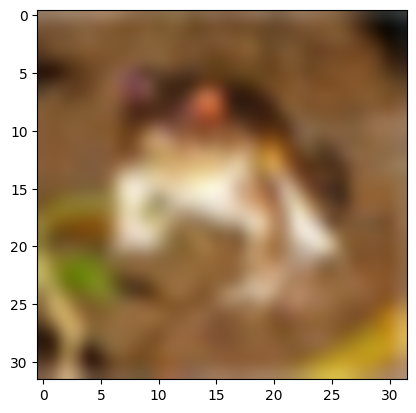

In [38]:
print(label)
plt.imshow(newimg, interpolation = 'bicubic') # -> added interpolation to convert very pixelated image to a bit smoother one

In [11]:
# We can directly jump to to DataLoader as it is not needed to convert the data into dataset

import os

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True,
                              num_workers = NUM_WORKERS)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = False,
                             num_workers = NUM_WORKERS)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7b2b29a1c530>,
 <torch.utils.data.dataloader.DataLoader at 0x7b2b29a1c740>)

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [13]:
# Let's create model class - a TinyVGG look-a-like mdoel

class TinyVGGV0(nn.Module):

  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):

    super().__init__()

    self.layer_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.layer_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units*8*8,
        out_features = output_shape)
    )

  def forward(self, x):
    x = self.layer_block_1(x)
    #print(f'shape of x after 1st block: {x.shape}')
    x = self.layer_block_2(x)
    #print(f'shape of x after 2nd block: {x.shape}')
    x = self.classifier(x)
    #print(f'shape of x after classifier: {x.shape}')
    return x

In [14]:
model_0 = TinyVGGV0(input_shape=3,
                    hidden_units = 32,
                    output_shape = len(train_data.classes)).to(device)

model_0

TinyVGGV0(
  (layer_block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=10, bias=True)
  )
)

In [15]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

In [16]:
from torchinfo import summary

summary(model_0, input_size = [32,3,32,32])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGGV0                                [32, 10]                  --
├─Sequential: 1-1                        [32, 32, 16, 16]          --
│    └─Conv2d: 2-1                       [32, 32, 32, 32]          896
│    └─ReLU: 2-2                         [32, 32, 32, 32]          --
│    └─Conv2d: 2-3                       [32, 32, 32, 32]          9,248
│    └─ReLU: 2-4                         [32, 32, 32, 32]          --
│    └─MaxPool2d: 2-5                    [32, 32, 16, 16]          --
├─Sequential: 1-2                        [32, 32, 8, 8]            --
│    └─Conv2d: 2-6                       [32, 32, 16, 16]          9,248
│    └─ReLU: 2-7                         [32, 32, 16, 16]          --
│    └─Conv2d: 2-8                       [32, 32, 16, 16]          9,248
│    └─ReLU: 2-9                         [32, 32, 16, 16]          --
│    └─MaxPool2d: 2-10                   [32, 32, 8, 8]            --
├─Seq

In [17]:
# Before training let's keep loss function and optimizer ready

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(), lr = 0.001)

In [18]:
# Building training and testing loops

def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn = loss_fn,
               optimizer = optimizer,
               device = device):

  # start the training by putting the model into training mode
  model.train()

   # to accumulate the training loss and training accuracy, we will use the below 2 variables
  train_loss, train_acc = 0, 0

  for batch, (X_train,y_train) in enumerate(dataloader): # for batch no. loop through the dataloader to get the img (x) and label (y)

    # put the image and label on the right or desired device
    X_train, y_train = X_train.to(device), y_train.to(device)

    # we will do the gradients = 0 so no previous weights or gradients gets accumulated
    optimizer.zero_grad()

    # now we can do the forward pass
    y_train_logits = model(X_train)

    # calculate the loss
    loss = loss_fn(y_train_logits, y_train)
    train_loss += loss.item() # we will use the item() to get the float value rather than the entire tensors of loss values hence we didn't do .item() while calculating loss in order to avoid converting from tensors to float on the go. this would change the result

    # we will convert the logits we got from forward pass to the labels so we can check the accuracy between the predicted and actual labels
    y_train_labels = torch.argmax(y_train_logits, dim = 1)

    # on the go we will calculate the accuracy as well
    accuracy = ((y_train_labels == y_train).sum().item()/len(y_train_logits))
    train_acc += accuracy

    # loss backward
    loss.backward()

    # once we find the weights that needs to updated, we will update those using step
    optimizer.step()

  # let's calculate the average loss and accuracy over the training once all batches are done
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  return train_loss, train_acc


In [19]:
# Building testing loop function
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn = loss_fn,
              device = device):

  # once above are set, let's put the model in evaluation mode
  model.eval()

  # initializing test loss and accuracy variables to accumulate the loss and accuracy over the training and then calculating the average at the end
  test_loss, test_acc = 0, 0



  with torch.inference_mode():

    # define the batch, image and label loop
    for batch, (X_test, y_test) in enumerate(dataloader):

      # moving the test image and test label to the target device
      X_test, y_test = X_test.to(device), y_test.to(device)

      # forward pass. We will not do optimizer zero grad as we are not aiming for training hence we dont need to accumate the gradients
      y_test_logits = model(X_test)

      # calculate the loss
      loss = loss_fn(y_test_logits, y_test)
      test_loss += loss.item() # -> better to itemize here so we can convert the total loss tensor value to float value

      # let's convert the y_test_logits to labels
      y_test_labels = torch.argmax(y_test_logits, dim=1)

      # let's calculate accuracy
      acc = ((y_test_labels == y_test).sum().item()/len(y_test_logits))
      # here we are basically checking how many true boolean values we get, then we sum it and convert the sum number to a plain python value and divind this to the len og the test logits over the batch

      test_acc += acc

  test_loss /= len(dataloader)
  test_acc /= len(dataloader)

  return test_loss, test_acc



In [20]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# let's build a train function to make the train and test function work
def train(model: torch.nn.Module,
          trainDataLoader: torch.utils.data.DataLoader,
          testDataLoader: torch.utils.data.DataLoader,
          loss_fn = loss_fn,
          optimizer = optimizer,
          epochs = 20,
          device = device):

  results = {
      'train_loss': [],
      'train_acc': [],
      'test_loss': [],
      'test_acc': []
  }

  for epoch in range(epochs):

    train_loss, train_acc = train_step(model = model,
                                       dataloader = trainDataLoader,
                                       loss_fn = loss_fn,
                                       optimizer = optimizer,
                                       device = device)

    test_loss, test_acc = test_step(model = model,
                                    dataloader = testDataLoader,
                                    loss_fn = loss_fn,
                                    device = device)


    print(f'epochs: {epoch} | train loss: {train_loss:.4f} | train_acc: {train_acc:.2f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.2f}')

    results['train_loss'].append(train_loss)
    results['train_acc'].append(train_acc)
    results['test_loss'].append(test_loss)
    results['test_acc'].append(test_acc)

  return results

In [21]:
model_0_results = train(model = model_0,
                         trainDataLoader = train_dataloader,
                         testDataLoader = test_dataloader,
                         loss_fn = loss_fn,
                         optimizer = optimizer,
                         device = device)

model_0_results

epochs: 0 | train loss: 1.5191 | train_acc: 0.45 | test_loss: 1.2542 | test_acc: 0.55
epochs: 1 | train loss: 1.1235 | train_acc: 0.61 | test_loss: 1.0638 | test_acc: 0.63
epochs: 2 | train loss: 0.9733 | train_acc: 0.66 | test_loss: 0.9469 | test_acc: 0.67
epochs: 3 | train loss: 0.8945 | train_acc: 0.69 | test_loss: 0.8674 | test_acc: 0.70
epochs: 4 | train loss: 0.8328 | train_acc: 0.71 | test_loss: 0.8675 | test_acc: 0.70
epochs: 5 | train loss: 0.7905 | train_acc: 0.73 | test_loss: 0.8262 | test_acc: 0.71
epochs: 6 | train loss: 0.7537 | train_acc: 0.74 | test_loss: 0.8300 | test_acc: 0.71
epochs: 7 | train loss: 0.7273 | train_acc: 0.75 | test_loss: 0.8083 | test_acc: 0.72
epochs: 8 | train loss: 0.7011 | train_acc: 0.76 | test_loss: 0.8136 | test_acc: 0.72
epochs: 9 | train loss: 0.6790 | train_acc: 0.76 | test_loss: 0.7618 | test_acc: 0.74
epochs: 10 | train loss: 0.6585 | train_acc: 0.77 | test_loss: 0.7640 | test_acc: 0.74
epochs: 11 | train loss: 0.6425 | train_acc: 0.78 | t

{'train_loss': [1.5191213707091025,
  1.1234608824559686,
  0.973340069854862,
  0.8944761487664279,
  0.8328065800308342,
  0.7905209354689239,
  0.7537021907147733,
  0.7273279743189242,
  0.7010794127895065,
  0.6789920105624488,
  0.6585478654044299,
  0.6424811871213479,
  0.6300916065600768,
  0.6138625596283493,
  0.604150620775961,
  0.5946076180468899,
  0.5861569249279135,
  0.5742055920267898,
  0.564358445881882,
  0.558515555608448],
 'train_acc': [0.45325495841330776,
  0.6057861484325016,
  0.6593690019193857,
  0.6886996161228407,
  0.7100727767114523,
  0.7259876839411389,
  0.7387236084452975,
  0.7480206333973128,
  0.7565579014715291,
  0.7639955214331414,
  0.7704734484964811,
  0.7765315099168266,
  0.7820297504798465,
  0.7842890275111964,
  0.7908269353806782,
  0.7924464171465131,
  0.7973248560460653,
  0.7995241522712732,
  0.8045225527831094,
  0.8061020473448497],
 'test_loss': [1.2541840139288492,
  1.0638057526688987,
  0.9468685097206896,
  0.86735488802

In [34]:
def plot_curve(results):

  plt.figure(figsize=(7, 7))

  plt.subplot(1, 2, 1)
  plt.plot(results['train_loss'], label = 'train_loss')
  plt.plot(results['test_loss'], label = 'test_loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(results['train_acc'], label = 'train_acc')
  plt.plot(results['test_acc'], label = 'test_acc')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.show()

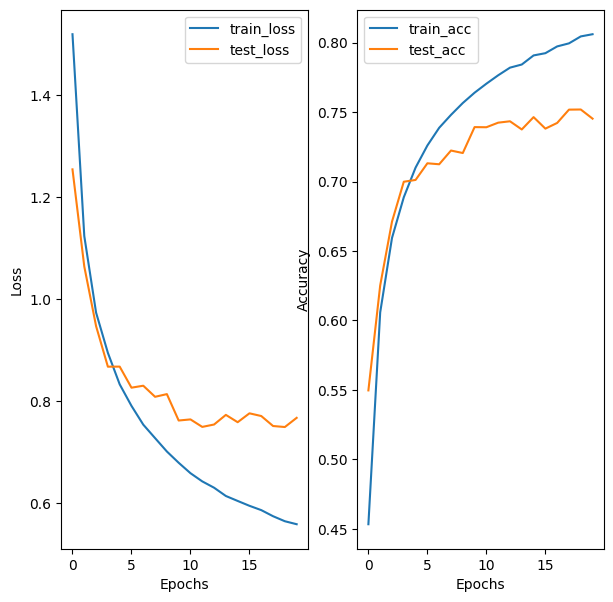

In [35]:
plot_curve(model_0_results)